In [1]:
# All Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
# Load Dataset
df = pd.read_excel("churn_dataset.xlsx")

print("Shape:", df.shape)
df.head()

Shape: (100, 4)


,Age,Tenure,Sex,Churn
0,56,8,Male,No
1,46,63,Female,No
2,32,11,Female,No
3,60,8,Male,No
4,25,35,Male,No


In [4]:
# Encode Categorical Columns
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df.head()

,Age,Tenure,Sex,Churn
0,56,8,1,0
1,46,63,0,0
2,32,11,0,0
3,60,8,1,0
4,25,35,1,0


In [5]:
# Check Missing Values
print(df.isnull().sum())
print("\nAny nulls?", df.isnull().any().any())

Age       0
Tenure    0
Sex       0
Churn     0
dtype: int64

Any nulls? False


In [6]:
# Split Data
X = df[['Age', 'Tenure', 'Sex']]   # Features
y = df['Churn']                     # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 80
Test size:  20


In [7]:
# Train Model
model = GaussianNB()
model.fit(X_train, y_train)

print("Model trained successfully ✓")

Model trained successfully ✓


In [12]:
# Accuracy Score
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8


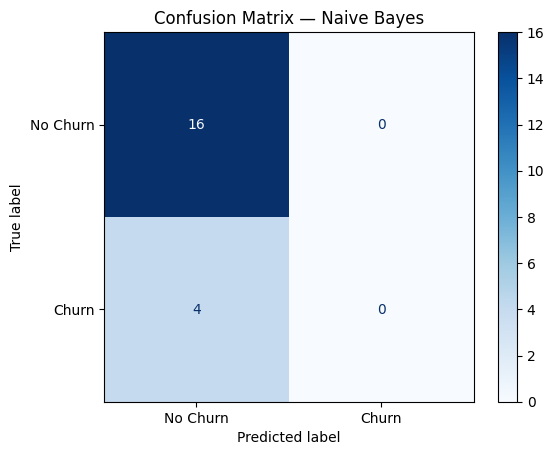

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Naive Bayes")
plt.show()